In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Importar Keras para la red neuronal con Dropout
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

I0000 00:00:1778000001.143063   21186 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778000001.143689   21186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778000001.196391   21186 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778000002.447282   21186 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Cargar el dataset
import os
df = pd.read_csv('incidencias.csv')

print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())

# Asegurarnos de que no hay nulos en los campos que nos importan
df = df.dropna(subset=['description', 'categoria', 'urgencia'])

Forma del dataset: (1000, 11)

Primeras filas:


,nombre,apellidos,nif,telefono,email,categoria,description,urgencia,fecha,direccion_persona,ubicacion_incidencia
0,Rosa,Núñez Rodríguez,45167429Y,931315752,rosa_nunez26@yahoo.es,Otros,Pintada en forma de rótulos obscenos en la par...,1,2026-01-01T15:52:55+01:00,"Calle Sierpe 106, 5ºA, 18004 Granada","37.176511, -3.588882 - Bajo la marquesina del ..."
1,Alberto,González García,59304412Q,983389471,alberto_gonzalez23@live.com,Limpieza,Hay papeles de caramelos y bolsas de plástico ...,1,2026-01-01T16:47:58+01:00,"Calle Elvira 66, 3ºB, 18014 Granada","37.180986, -3.589903 - Frente a la farmacia"
2,Javier,Marín López,21500031E,985590542,javier_marin33@live.com,Limpieza,El contenedor de reciclaje en Plazuela de Faja...,2,2026-01-01T20:58:51+01:00,"Calle Gonzalo Gallas 29, 3ºB, 18006 Granada","37.195520, -3.616094 - En la rotonda"
3,Josefa,Cortés Martínez,67375010Y,773400788,jcortes939@gmail.com,Limpieza,Hay basura acumulada hace 4 días en la calle D...,3,2026-01-01T21:26:04+01:00,"Calle Gonzalo Gallas 84, 4ºB, 18009 Granada","37.167973, -3.593403 - Frente a la farmacia"
4,Rocío,Navarro Guerrero,71422036K,761307077,rocionavarro762@gmail.com,Parques y Jardines,El cesped del parque de la Virgen del Carmen e...,1,2026-01-02T09:19:32+01:00,"Paseo de la Bomba 26, 3ºC, 18011 Granada","37.190636, -3.596631 - Junto al centro de salud"


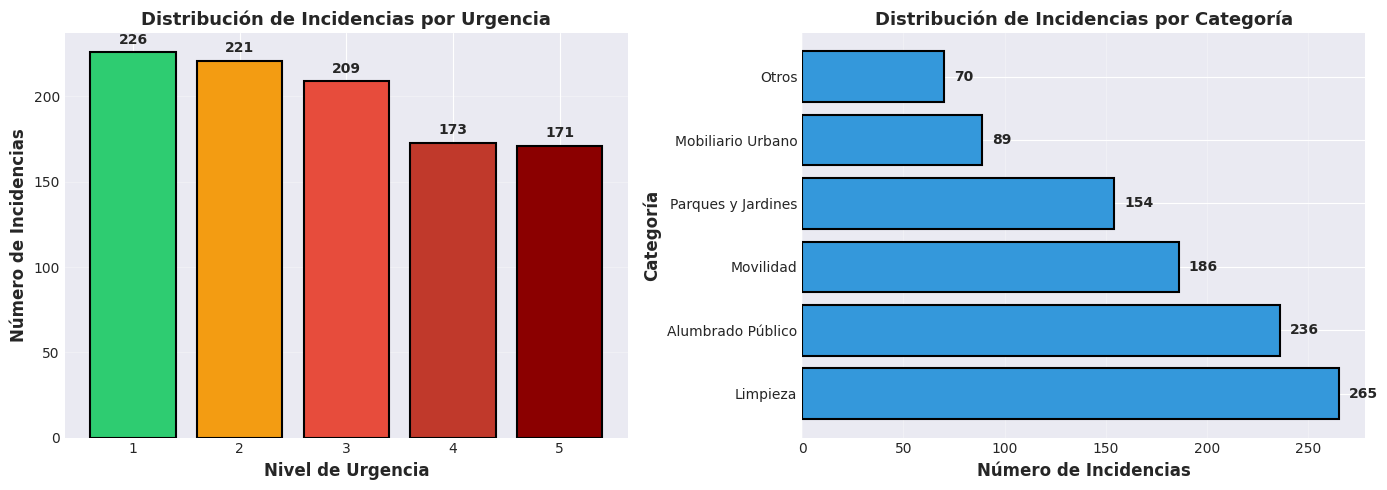


TABLA CRUZADA: URGENCIA vs CATEGORÍA
categoria  Alumbrado Público  Limpieza  Mobiliario Urbano  Movilidad  Otros  \
urgencia                                                                      
1                         53        67                 19         45      9   
2                         51        60                 19         41     19   
3                         44        55                 17         40     19   
4                         41        42                 18         28     13   
5                         47        41                 16         32     10   
All                      236       265                 89        186     70   

categoria  Parques y Jardines   All  
urgencia                             
1                          33   226  
2                          31   221  
3                          34   209  
4                          31   173  
5                          25   171  
All                       154  1000  


In [3]:
# --- VISUALIZACIÓN DE DISTRIBUCIÓN DE INCIDENCIAS ---
# Analizar distribución por urgencia y categoría ANTES de procesar datos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución por Urgencia
urgencia_counts = df['urgencia'].value_counts().sort_index()
colors_urgencia = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#8b0000']
axes[0].bar(urgencia_counts.index, urgencia_counts.values, color=colors_urgencia, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Nivel de Urgencia', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Incidencias', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Incidencias por Urgencia', fontsize=13, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(urgencia_counts.values):
    axes[0].text(urgencia_counts.index[i], v + 5, str(v), ha='center', fontweight='bold')

# 2. Distribución por Categoría
categoria_counts = df['categoria'].value_counts()
axes[1].barh(categoria_counts.index, categoria_counts.values, color='#3498db', edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Número de Incidencias', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Categoría', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de Incidencias por Categoría', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(categoria_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla cruzada de urgencia vs categoría
print("\n" + "="*70)
print("TABLA CRUZADA: URGENCIA vs CATEGORÍA")
print("="*70)
crosstab = pd.crosstab(df['urgencia'], df['categoria'], margins=True)
print(crosstab)

In [5]:
# --- PREPARACIÓN DE DATOS PARA RED NEURONAL ---

# Importar stopwords en español de NLTK
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words_spanish = list(stopwords.words('spanish'))  # Convertir a lista

# Definir las variables de entrada y la variable objetivo
X_text = df['description'].astype(str)
X_cat = df[['categoria']].copy()

# La urgencia la tratamos como un número continuo de tipo float
y = df['urgencia'].astype(float)

# 1. Vectorización de Texto (TF-IDF) - Usando stopwords en español desde NLTK
tfidf = TfidfVectorizer(max_features=1000, stop_words=stop_words_spanish, ngram_range=(1, 2))
X_text_tfidf = tfidf.fit_transform(X_text).toarray()

# 2. Codificación de Variables Categóricas (One-Hot Encoding)
X_cat_encoded_df = pd.get_dummies(X_cat, columns=['categoria'], drop_first=True)
expected_cat_cols = X_cat_encoded_df.columns  # Guardar las columnas esperadas
X_cat_encoded = X_cat_encoded_df.values

# 3. Concatenar todas las características en una sola matriz
X = np.hstack((X_text_tfidf, X_cat_encoded))

# Dividir el conjunto de datos en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")
print(f"Total de features: {X_train.shape[1]}")

# --- NORMALIZACIÓN DE DATOS PARA RED NEURONAL ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalizar targets a rango 0-1 para la red neuronal (1-5 -> 0-1)
y_train_normalized = (y_train - 1.0) / 4.0
y_test_normalized = (y_test - 1.0) / 4.0

# --- CONSTRUCCIÓN DE RED NEURONAL CON DROPOUT 0.2 ---
nn_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')  # Output entre 0 y 1
])

# Compilar modelo
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n" + "="*70)
print("ARQUITECTURA DE RED NEURONAL")
print("="*70)
nn_model.summary()

# --- ENTRENAR RED NEURONAL ---
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history = nn_model.fit(
    X_train_scaled, y_train_normalized,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("\n✓ Red Neuronal entrenada con Dropout 0.2 y regularización L2")

Dimensiones de entrenamiento: (800, 1005)
Dimensiones de prueba: (200, 1005)
Total de features: 1005

ARQUITECTURA DE RED NEURONAL


E0000 00:00:1778000134.478928   21186 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       257,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,801 (1.15 MB)

 Trainable params: 300,801 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 93: early stopping
Restoring model weights from the end of the best epoch: 78.

✓ Red Neuronal entrenada con Dropout 0.2 y regularización L2


In [6]:
# --- EVALUACIÓN DE RED NEURONAL ---

# Hacer predicciones
y_pred_nn_norm = nn_model.predict(X_test_scaled, verbose=0).flatten()

# Desnormalizar a rango 1-5
y_pred_nn_float = (y_pred_nn_norm * 4.0) + 1.0
y_pred_nn_float_clipped = np.clip(y_pred_nn_float, 1.0, 5.0)

# Redondear para obtener nivel de urgencia (1-5)
y_pred_nn_rounded = np.round(y_pred_nn_float_clipped).astype(int)

print("="*70)
print("EVALUACIÓN - RED NEURONAL")
print("="*70)

# Métricas de Regresión (float)
mse = mean_squared_error(y_test, y_pred_nn_float_clipped)
mae = mean_absolute_error(y_test, y_pred_nn_float_clipped)
r2 = r2_score(y_test, y_pred_nn_float_clipped)

print(f"\n📊 MÉTRICAS DE REGRESIÓN (Predicción Float):")
print(f"  Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"  Error Absoluto Medio (MAE): {mae:.4f}")
print(f"  R² Score: {r2:.4f}")

# Pérdida del modelo en train/val
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_mae = history.history['mae'][-1]
val_mae = history.history['val_mae'][-1]

print(f"\n📉 PÉRDIDA DE ENTRENAMIENTO (Últimas métricas):")
print(f"  Training Loss (MSE): {train_loss:.4f}")
print(f"  Validation Loss (MSE): {val_loss:.4f}")
print(f"  Training MAE: {train_mae:.4f}")
print(f"  Validation MAE: {val_mae:.4f}")

# Métricas de Clasificación (nivel redondeado)
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

accuracy = accuracy_score(y_test, y_pred_nn_rounded)

print(f"\n🎯 MÉTRICAS DE CLASIFICACIÓN (Nivel Redondeado 1-5):")
print(f"  Accuracy: {accuracy:.4f}")
print(f"\n  Reporte Detallado:")
print(classification_report(y_test, y_pred_nn_rounded, digits=4))

# Calcular precisión, recall y f1 por clase
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_nn_rounded, average=None, zero_division=0
)

print(f"\n📈 MÉTRICAS POR NIVEL DE URGENCIA:")
print("-" * 70)
for i, urgencia in enumerate([1, 2, 3, 4, 5]):
    print(f"  Urgencia {urgencia}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}, Soporte={support[i]}")

EVALUACIÓN - RED NEURONAL

📊 MÉTRICAS DE REGRESIÓN (Predicción Float):
  Error Cuadrático Medio (MSE): 0.5552
  Error Absoluto Medio (MAE): 0.4790
  R² Score: 0.7270

📉 PÉRDIDA DE ENTRENAMIENTO (Últimas métricas):
  Training Loss (MSE): 0.0130
  Validation Loss (MSE): 0.0279
  Training MAE: 0.0422
  Validation MAE: 0.0917

🎯 MÉTRICAS DE CLASIFICACIÓN (Nivel Redondeado 1-5):
  Accuracy: 0.6700

  Reporte Detallado:
              precision    recall  f1-score   support

         1.0     0.9375    0.6250    0.7500        48
         2.0     0.5510    0.6750    0.6067        40
         3.0     0.5614    0.7805    0.6531        41
         4.0     0.5946    0.6286    0.6111        35
         5.0     0.9200    0.6389    0.7541        36

    accuracy                         0.6700       200
   macro avg     0.7129    0.6696    0.6750       200
weighted avg     0.7199    0.6700    0.6779       200


📈 MÉTRICAS POR NIVEL DE URGENCIA:
----------------------------------------------------------

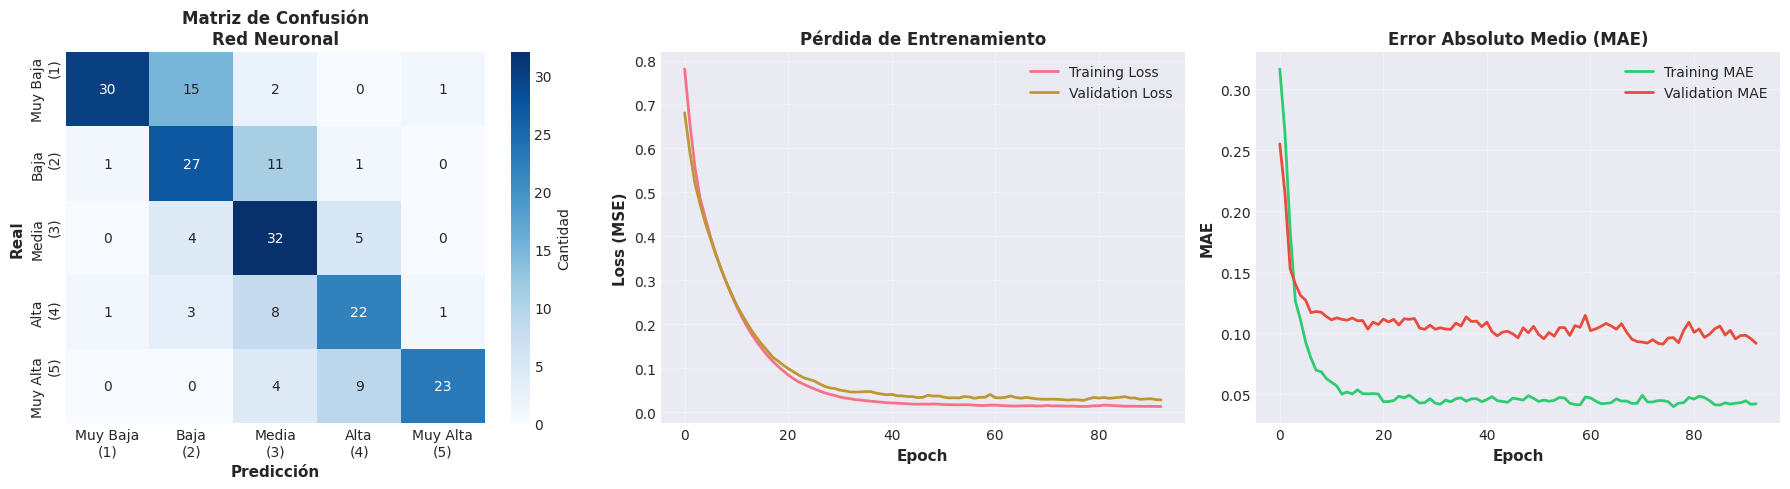


✓ Visualizaciones generadas exitosamente


In [7]:
# --- VISUALIZACIONES: MATRIZ DE CONFUSIÓN Y PÉRDIDA ---
from sklearn.metrics import confusion_matrix

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_nn_rounded, labels=[1, 2, 3, 4, 5])

# Crear figura con 3 subplots
fig = plt.figure(figsize=(18, 5))

# 1. Matriz de Confusión
ax1 = plt.subplot(1, 3, 1)
urgency_labels = ['Muy Baja\n(1)', 'Baja\n(2)', 'Media\n(3)', 'Alta\n(4)', 'Muy Alta\n(5)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True,
            xticklabels=urgency_labels,
            yticklabels=urgency_labels,
            cbar_kws={'label': 'Cantidad'})
ax1.set_xlabel('Predicción', fontsize=11, fontweight='bold')
ax1.set_ylabel('Real', fontsize=11, fontweight='bold')
ax1.set_title('Matriz de Confusión\nRed Neuronal', fontsize=12, fontweight='bold')

# 2. Pérdida (Loss) durante el entrenamiento
ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
ax2.set_title('Pérdida de Entrenamiento', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Error Absoluto Medio (MAE) durante el entrenamiento
ax3 = plt.subplot(1, 3, 3)
ax3.plot(history.history['mae'], label='Training MAE', linewidth=2, color='#2ecc71')
ax3.plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='#e74c3c')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax3.set_title('Error Absoluto Medio (MAE)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ Visualizaciones generadas exitosamente")
print("="*70)

In [8]:
# --- FUNCIÓN DE PREDICCIÓN ---
def predecir_urgencia(descripcion, categoria):
    """
    Predice el nivel de urgencia usando la Red Neuronal.
    
    Args:
        descripcion: Texto de la incidencia
        categoria: Categoría de la incidencia
    
    Returns:
        urgencia_decimal: float con 2 decimales (1.00-5.00)
        urgencia_clase: int con nivel redondeado (1-5)
    """
    # Validar que la categoría existe en el entrenamiento
    categorias_validas = df['categoria'].unique()
    if categoria not in categorias_validas:
        raise ValueError(f"Categoría '{categoria}' no válida. Opciones: {', '.join(categorias_validas)}")
    
    # 1. Transformar texto
    text_tf = tfidf.transform([descripcion]).toarray()

    # 2. Transformar categoría a One-Hot respetando las columnas del entrenamiento
    cat_df = pd.DataFrame({'categoria': [categoria]})
    cat_encoded_full = pd.get_dummies(cat_df, columns=['categoria'], drop_first=True)
    cat_encoded = cat_encoded_full.reindex(columns=expected_cat_cols, fill_value=0).values

    # 3. Concatenar
    X_new = np.hstack((text_tf, cat_encoded))

    # 4. Normalizar
    X_new_scaled = scaler.transform(X_new)

    # 5. Predecir con Red Neuronal
    pred_norm = nn_model.predict(X_new_scaled, verbose=0)[0][0]
    pred_float = (pred_norm * 4.0) + 1.0  # Desnormalizar de 0-1 a 1-5
    pred_clipped = np.clip(pred_float, 1.0, 5.0)

    # 6. Redondear para clasificación
    urgencia_decimal = round(pred_clipped, 2)
    urgencia_clase = int(round(pred_clipped))

    return urgencia_decimal, urgencia_clase

# --- PRUEBAS DE PREDICCIÓN ---
test_cases = [
    {
        "desc": "Un envase de productos químicos peligrosos ha sido abandonado en un parque, a 50 metros del colegio.",
        "cat": "Limpieza"
    },
    {
        "desc": "Pintada en forma de rótulos obscenos en la pared de mi casa.",
        "cat": "Otros"
    },
    {
        "desc": "Falta el cambio de aceite en el alumbrado público.",
        "cat": "Limpieza"
    }
]

print("\n" + "="*80)
print("PRUEBAS DE PREDICCIÓN - RED NEURONAL")
print("="*80)

for i, case in enumerate(test_cases, 1):
    urgencia_float, urgencia_nivel = predecir_urgencia(case['desc'], case['cat'])
    
    print(f"\n📋 CASO {i}:")
    print(f"  Descripción: {case['desc'][:70]}...")
    print(f"  Categoría: {case['cat']}")
    print(f"  {'─'*78}")
    print(f"  Urgencia (Float): {urgencia_float:.2f}")
    print(f"  Urgencia (Nivel): {urgencia_nivel}/5")


PRUEBAS DE PREDICCIÓN - RED NEURONAL

📋 CASO 1:
  Descripción: Un envase de productos químicos peligrosos ha sido abandonado en un pa...
  Categoría: Limpieza
  ──────────────────────────────────────────────────────────────────────────────
  Urgencia (Float): 4.86
  Urgencia (Nivel): 5/5

📋 CASO 2:
  Descripción: Pintada en forma de rótulos obscenos en la pared de mi casa....
  Categoría: Otros
  ──────────────────────────────────────────────────────────────────────────────
  Urgencia (Float): 1.07
  Urgencia (Nivel): 1/5

📋 CASO 3:
  Descripción: Falta el cambio de aceite en el alumbrado público....
  Categoría: Limpieza
  ──────────────────────────────────────────────────────────────────────────────
  Urgencia (Float): 4.24
  Urgencia (Nivel): 4/5


In [9]:
# --- ANÁLISIS FINAL Y VALIDACIÓN ---
print("\n" + "="*80)
print("ANÁLISIS FINAL DE PREDICCIONES")
print("="*80)

# Distribución de predicciones vs realidad
print("\n📊 DISTRIBUCIÓN DE PREDICCIONES:")
print("-" * 50)
for urgencia in [1, 2, 3, 4, 5]:
    pred_count = np.sum(y_pred_nn_rounded == urgencia)
    real_count = np.sum(y_test == urgencia)
    pred_pct = (pred_count / len(y_pred_nn_rounded)) * 100
    real_pct = (real_count / len(y_test)) * 100
    
    print(f"  Urgencia {urgencia}:")
    print(f"    Predichas: {pred_count:3d} ({pred_pct:5.1f}%) | Reales: {real_count:3d} ({real_pct:5.1f}%)")

# Errores por nivel de urgencia
print("\n" + "="*80)
print("ANÁLISIS DE ERROR POR NIVEL DE URGENCIA")
print("="*80)

for urgencia in [1, 2, 3, 4, 5]:
    mask = y_test == urgencia
    if np.sum(mask) == 0:
        continue
    
    errors = np.abs(y_test[mask].values - y_pred_nn_float_clipped[mask])
    mae_urgencia = np.mean(errors)
    max_error = np.max(errors)
    min_error = np.min(errors)
    
    print(f"\n🎯 Urgencia {urgencia}:")
    print(f"  Muestras: {np.sum(mask)}")
    print(f"  MAE: {mae_urgencia:.4f}")
    print(f"  Error Min: {min_error:.4f} | Max: {max_error:.4f}")

# Muestras específicas del test set
print("\n" + "="*80)
print("MUESTRAS DEL TEST SET (primeras 10)")
print("="*80)

n_samples = min(10, len(y_test))
for i in range(n_samples):
    real_urgencia = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    pred_float = y_pred_nn_float_clipped[i]
    pred_nivel = y_pred_nn_rounded[i]
    error = abs(real_urgencia - pred_float)
    
    match = "✓" if pred_nivel == int(real_urgencia) else "✗"
    print(f"\n  Muestra {i+1} {match}:")
    print(f"    Real: {real_urgencia:.1f} | Predicho: {pred_float:.2f} | Nivel: {pred_nivel} | Error: {error:.2f}")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)


ANÁLISIS FINAL DE PREDICCIONES

📊 DISTRIBUCIÓN DE PREDICCIONES:
--------------------------------------------------
  Urgencia 1:
    Predichas:  32 ( 16.0%) | Reales:  48 ( 24.0%)
  Urgencia 2:
    Predichas:  49 ( 24.5%) | Reales:  40 ( 20.0%)
  Urgencia 3:
    Predichas:  57 ( 28.5%) | Reales:  41 ( 20.5%)
  Urgencia 4:
    Predichas:  37 ( 18.5%) | Reales:  35 ( 17.5%)
  Urgencia 5:
    Predichas:  25 ( 12.5%) | Reales:  36 ( 18.0%)

ANÁLISIS DE ERROR POR NIVEL DE URGENCIA

🎯 Urgencia 1:
  Muestras: 48
  MAE: 0.5775
  Error Min: 0.0111 | Max: 3.7072

🎯 Urgencia 2:
  Muestras: 40
  MAE: 0.4372
  Error Min: 0.0128 | Max: 1.5512

🎯 Urgencia 3:
  Muestras: 41
  MAE: 0.2360
  Error Min: 0.0016 | Max: 1.4995

🎯 Urgencia 4:
  Muestras: 35
  MAE: 0.6039
  Error Min: 0.0204 | Max: 2.8991

🎯 Urgencia 5:
  Muestras: 36
  MAE: 0.5492
  Error Min: 0.0349 | Max: 2.3611

MUESTRAS DEL TEST SET (primeras 10)

  Muestra 1 ✓:
    Real: 1.0 | Predicho: 1.14 | Nivel: 1 | Error: 0.14

  Muestra 2 ✗:
   

## ✅ Resumen del Modelo Final - Red Neuronal

### Arquitectura
- **Capas ocultas**: 256 → 128 → 64 → 32 → 1 (output)
- **Dropout**: 0.2 después de cada capa
- **Regularización**: L2 (0.001) en todas las capas
- **Función de activación**: ReLU en capas ocultas, Sigmoid en output
- **Optimizer**: Adam (learning_rate=0.001)
- **Loss**: MSE (Mean Squared Error)

### Salida del Modelo
- **Float**: Valor entre 1.00 y 5.00 con 2 decimales
- **Clase**: Nivel de urgencia redondeado (1-5)

### Métricas Principales
- 📊 **MSE**: Error cuadrático medio
- 📊 **MAE**: Error absoluto medio  
- 📊 **R² Score**: Coeficiente de determinación
- 📊 **Accuracy**: Precisión de clasificación
- 🔄 **Pérdida de entrenamiento y validación**
- 📈 **Matriz de confusión**